In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import sklearn

In [18]:
data_dir = Path('match_folder/2025-2026')

df = pd.concat(
        pd.read_parquet(parquet_file)
        for parquet_file in data_dir.glob('*.parquet')
    )

# Mirror shots on the Y axis, as the origin in the scraped data is top left, while mine is in bottom left.
df['Y'] = 20 - df['Y']
# Encode the shot outcome into binary variable for xG calculation.
df['is_goal'] = (df['Shot outcome'].eq('shot_goal')).astype('Int8')


In [55]:
def make_features(df):
    dx = (1.75 + 0.65) - df['X'].values
    dy = 10 - df['Y'].values
    dist = np.hypot(dx, dy)
    # simple angle proxy: absolute lateral angle to goal center
    angle = np.arctan2(np.abs(dy), np.maximum(dx, 1e-6))  # avoid division by 0 near goal line
    X = pd.DataFrame({
        'dist': dist,
        'angle': angle,
        'log_dist': np.log(dist + 1e-6),
        'angle2': angle**2,
        'dist2': dist**2,
        'dist_angle': dist * angle,
    })
    return X

features = make_features(df)
label = df['is_goal']
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=78, shuffle=True)

In [56]:
log_regr = LogisticRegression(penalty='l2',C=1.0, solver='lbfgs', max_iter=1000, class_weight=None)
log_regr.fit(X_train, y_train)
p_pred = log_regr.predict_proba(X_test)[:, 1]

print("Log loss:", sklearn.metrics.log_loss(y_test, p_pred))
print("Brier score:", sklearn.metrics.brier_score_loss(y_test, p_pred))
print("ROC AUC:", sklearn.metrics.roc_auc_score(y_test, p_pred))


p = y_train.mean()
p_const = np.full_like(y_test, p, dtype=float)
print("Baseline (const mean) - log loss:", sklearn.metrics.log_loss(y_test, p_const))
print("Baseline (const mean) - Brier:", sklearn.metrics.brier_score_loss(y_test, p_const))
print("Prevalence p:", p)

Log loss: 0.34257816417887993
Brier score: 0.0995222456364794
ROC AUC: 0.6828742838358224
Baseline (const mean) - log loss: 0.3653907253008965
Baseline (const mean) - Brier: 0.10500616469805607
Prevalence p: 0.1159235668789809


/tmp/ipykernel_37760/400358463.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_d = pd.DataFrame({'rate': pd.Series(label).groupby(dcat).mean(), 'n': pd.Series(label).groupby(dcat).size()})


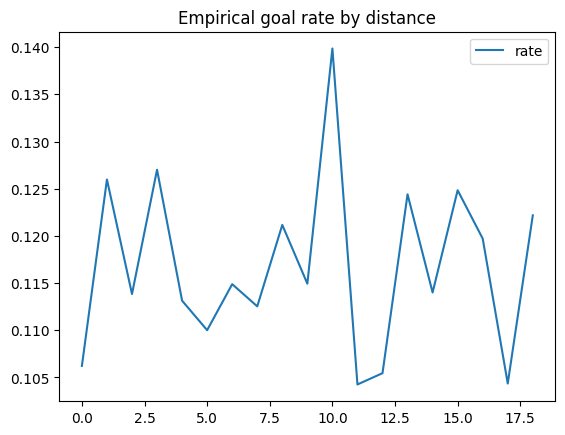

In [57]:
import matplotlib.pyplot as plt
# 1D sanity: goal rate by distance
bins = np.linspace(np.percentile(features['dist'], 1), np.percentile(features['dist'], 99), 20)
dcat = pd.cut(features['dist'], bins)
by_d = pd.DataFrame({'rate': pd.Series(label).groupby(dcat).mean(), 'n': pd.Series(label).groupby(dcat).size()})
by_d.plot(y='rate', use_index=False, title='Empirical goal rate by distance'); plt.show()


In [58]:
np.quantile(p_pred, [0, .25, .5, .75, 1])

array([0.03277419, 0.0594844 , 0.08429055, 0.14437323, 0.45797209])